# 🤖 Machine Learning – World Bank PIB
## Grupo 8 – Zambrano & Chala
### Modelos implementados:
1. **Regresión Lineal** – Predicción del PIB per cápita de Colombia
2. **Random Forest** – Predicción del crecimiento del PIB
3. **K-Means Clustering** – Agrupación de países por similitud económica

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
import os
warnings.filterwarnings('ignore')

# Buscar el CSV en múltiples rutas posibles
rutas = [
    'worldbank_pib.csv',
    '../data/worldbank_pib.csv',
    'data/worldbank_pib.csv',
    '../../02-Elt-Proyecto-Api/data/worldbank_pib.csv'
]

df = None
for r in rutas:
    if os.path.exists(r):
        df = pd.read_csv(r)
        print(f'✅ Datos cargados desde: {r}')
        break

if df is None:
    print('❌ No se encontró el CSV. Usando datos de ejemplo...')
    # Datos de ejemplo si no hay CSV
    paises = ['CO','BR','MX','AR','CL','PE','US']
    anios  = list(range(2000, 2024))
    filas  = []
    np.random.seed(42)
    pib_pc_base = {'CO':2000,'BR':3000,'MX':4000,'AR':5000,'CL':6000,'PE':2500,'US':35000}
    for p in paises:
        pib = pib_pc_base[p]
        for a in anios:
            crec = np.random.normal(3, 2)
            pib  = pib * (1 + crec/100)
            filas.append({
                'pais_codigo': p,
                'pais_nombre': p,
                'anio': a,
                'pib_per_capita_usd': round(pib, 2),
                'crecimiento_pib_pct': round(crec, 2),
                'inflacion_pct': round(np.random.normal(4, 2), 2),
                'desempleo_pct': round(np.random.normal(9, 3), 2),
                'exportaciones_pct_pib': round(np.random.uniform(15, 30), 2),
                'importaciones_pct_pib': round(np.random.uniform(15, 30), 2),
                'region': 'América Latina' if p != 'US' else 'Referencia',
                'es_colombia': p == 'CO'
            })
    df = pd.DataFrame(filas)
    print('✅ Datos de ejemplo generados')

df['anio'] = df['anio'].astype(int)
print(f'Shape: {df.shape}')
df.head()

✅ Datos cargados desde: worldbank_pib.csv
Shape: (168, 13)


,pais_codigo,pais_nombre,anio,pib_usd,crecimiento_pib_pct,pib_per_capita_usd,inflacion_pct,desempleo_pct,exportaciones_pct_pib,importaciones_pct_pib,fecha_extraccion,region,es_colombia
0,AR,Argentina,2000,2.842038e+11,-0.788999,7637.014892,NaN,15.000,10.986375,11.636070,2026-03-04T16:36:05.751730,América Latina,False
1,AR,Argentina,2001,2.686968e+11,-4.408840,7141.475077,NaN,17.320,11.579008,10.273247,2026-03-04T16:36:05.751730,América Latina,False
2,AR,Argentina,2002,9.772400e+10,-10.894485,2569.699635,NaN,19.590,28.382597,13.370127,2026-03-04T16:36:05.751730,América Latina,False
3,AR,Argentina,2003,1.275870e+11,8.837041,3320.477751,NaN,15.360,25.930943,14.713805,2026-03-04T16:36:05.751730,América Latina,False
4,AR,Argentina,2004,1.646579e+11,9.029573,4242.020991,NaN,13.522,23.847619,16.845027,2026-03-04T16:36:05.751730,América Latina,False


## 1. Exploración de Datos (EDA)

In [2]:
print('Países:', df['pais_codigo'].unique().tolist())
print('Años:  ', df['anio'].min(), '-', df['anio'].max())
print('\nValores nulos:')
print(df.isnull().sum())
print('\nEstadísticas descriptivas:')
df.describe().round(2)

Países: ['AR', 'BR', 'CL', 'CO', 'MX', 'PE', 'US']
Años:   2000 - 2023

Valores nulos:
pais_codigo               0
pais_nombre               0
anio                      0
pib_usd                   0
crecimiento_pib_pct       0
pib_per_capita_usd        0
inflacion_pct            18
desempleo_pct             0
exportaciones_pct_pib     0
importaciones_pct_pib     0
fecha_extraccion          0
region                    0
es_colombia               0
dtype: int64

Estadísticas descriptivas:


,anio,pib_usd,crecimiento_pib_pct,pib_per_capita_usd,inflacion_pct,desempleo_pct,exportaciones_pct_pib,importaciones_pct_pib
count,168.00,1.680000e+02,168.00,168.00,150.00,168.00,168.00,168.00
mean,2011.50,2.936610e+12,2.77,14695.12,6.71,7.73,21.42,21.61
std,6.94,5.960055e+12,3.90,16772.12,13.72,3.56,9.15,7.97
min,2000.00,5.174475e+10,-10.93,1929.57,-0.36,2.63,9.04,10.27
25%,2005.75,2.212106e+11,1.35,6196.11,2.81,4.69,13.58,14.72
50%,2011.50,4.356911e+11,2.91,8874.80,3.77,7.54,18.28,19.92
75%,2017.25,1.414569e+12,4.97,13185.27,5.87,9.99,28.34,27.90
max,2023.00,2.729217e+13,13.36,81032.26,133.49,20.52,45.13,45.87


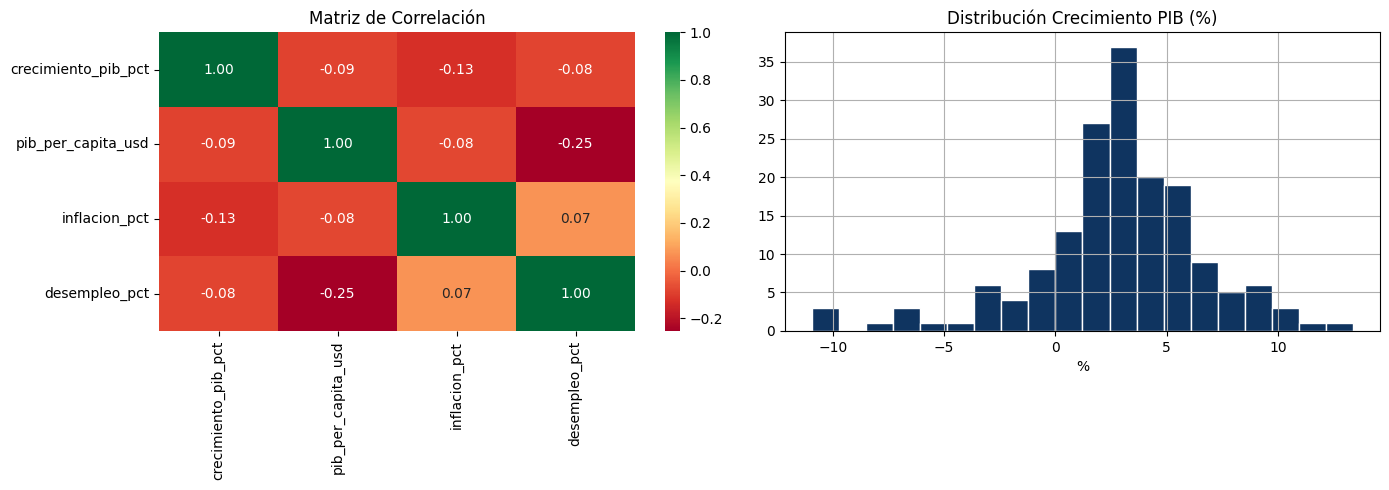

In [3]:
cols_num = ['crecimiento_pib_pct','pib_per_capita_usd','inflacion_pct','desempleo_pct']
df_corr  = df[cols_num].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0])
axes[0].set_title('Matriz de Correlación')

df['crecimiento_pib_pct'].dropna().hist(bins=20, ax=axes[1], color='#0f3460', edgecolor='white')
axes[1].set_title('Distribución Crecimiento PIB (%)')
axes[1].set_xlabel('%')
plt.tight_layout()
plt.show()

## 2. Modelo 1: Regresión Lineal – Predicción PIB Per Cápita Colombia

In [4]:
co = df[df['pais_codigo'] == 'CO'].dropna(subset=['pib_per_capita_usd','anio']).copy()

X = co[['anio']]
y = co['pib_per_capita_usd']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred = modelo_lr.predict(X_test)

print('=== Regresión Lineal – PIB Per Cápita Colombia ===')
print(f'R²:   {r2_score(y_test, y_pred):.4f}')
print(f'MAE:  ${mean_absolute_error(y_test, y_pred):,.0f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}')

futuros = pd.DataFrame({'anio': [2024, 2025, 2026, 2027]})
predicciones = modelo_lr.predict(futuros)
print('\nPredicciones futuras Colombia:')
for a, p in zip(futuros['anio'], predicciones):
    print(f'  {a}: ${p:,.0f} USD per cápita')

=== Regresión Lineal – PIB Per Cápita Colombia ===
R²:   0.5933
MAE:  $781
RMSE: $1,071

Predicciones futuras Colombia:
  2024: $7,965 USD per cápita
  2025: $8,174 USD per cápita
  2026: $8,382 USD per cápita
  2027: $8,591 USD per cápita


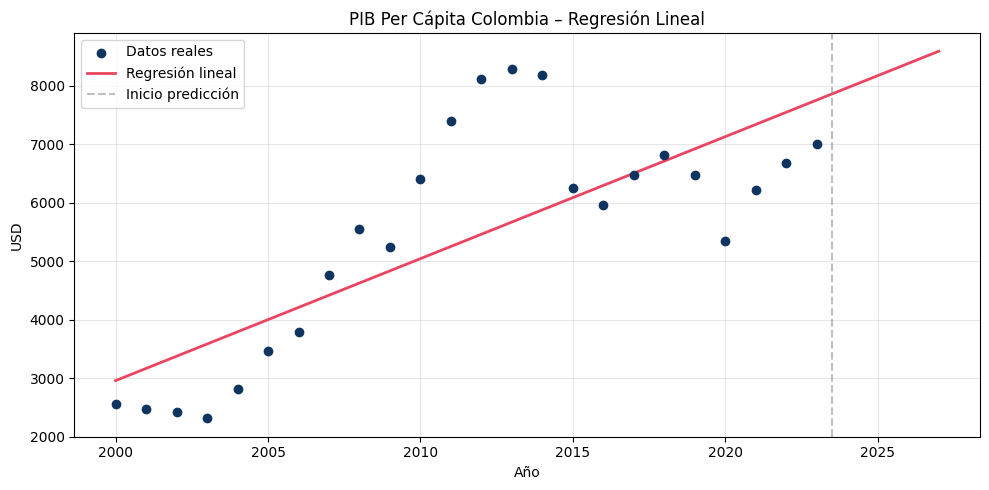

In [5]:
plt.figure(figsize=(10, 5))
plt.scatter(co['anio'], co['pib_per_capita_usd'], color='#0f3460', label='Datos reales', zorder=5)
anios_linea = np.arange(co['anio'].min(), 2028).reshape(-1, 1)
plt.plot(anios_linea, modelo_lr.predict(anios_linea), color='#e94560', linewidth=2, label='Regresión lineal')
plt.axvline(x=2023.5, color='gray', linestyle='--', alpha=0.5, label='Inicio predicción')
plt.title('PIB Per Cápita Colombia – Regresión Lineal')
plt.xlabel('Año')
plt.ylabel('USD')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Modelo 2: Random Forest – Predicción Crecimiento PIB

In [6]:
features = ['pib_per_capita_usd','inflacion_pct','desempleo_pct',
            'exportaciones_pct_pib','importaciones_pct_pib']
target   = 'crecimiento_pib_pct'

# Usar solo columnas que existan
features = [f for f in features if f in df.columns]
df_ml    = df.dropna(subset=features + [target]).copy()

X = df_ml[features]
y = df_ml[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print('=== Random Forest – Crecimiento PIB ===')
print(f'R²:   {r2_score(y_test, y_pred_rf):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_rf):.4f}%')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}%')

importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=False)
print('\nImportancia de variables:')
print(importancias.round(4))

=== Random Forest – Crecimiento PIB ===
R²:   -0.1620
MAE:  1.8131%
RMSE: 2.4357%

Importancia de variables:
inflacion_pct            0.2471
pib_per_capita_usd       0.2283
desempleo_pct            0.2028
importaciones_pct_pib    0.1687
exportaciones_pct_pib    0.1530
dtype: float64


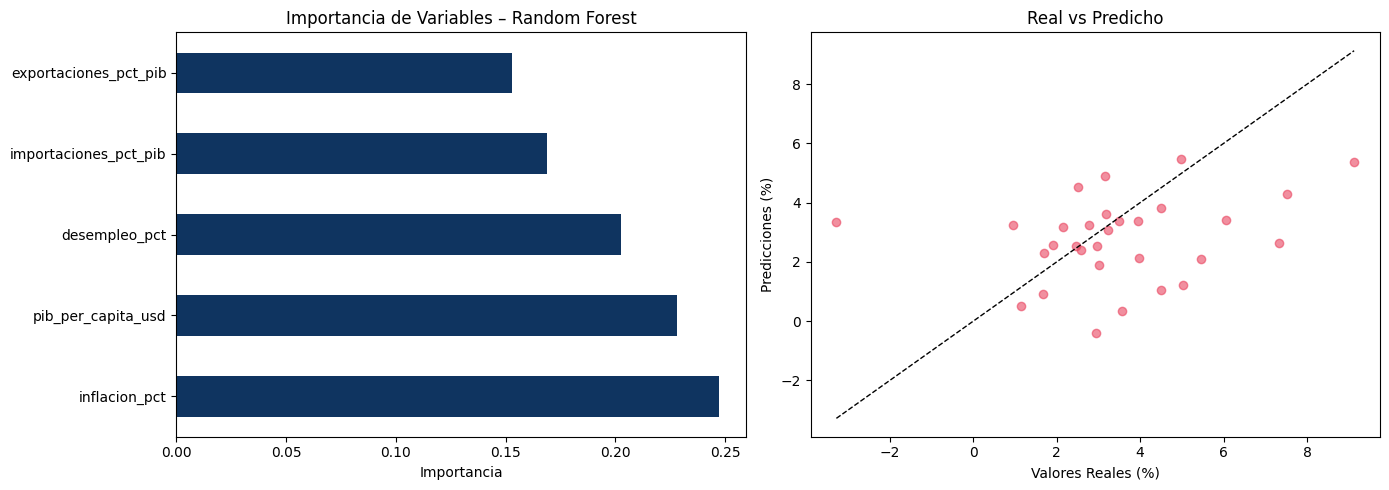

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
importancias.plot(kind='barh', ax=axes[0], color='#0f3460')
axes[0].set_title('Importancia de Variables – Random Forest')
axes[0].set_xlabel('Importancia')

axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='#e94560')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
axes[1].set_xlabel('Valores Reales (%)')
axes[1].set_ylabel('Predicciones (%)')
axes[1].set_title('Real vs Predicho')
plt.tight_layout()
plt.show()

## 4. Modelo 3: K-Means Clustering – Agrupación de Países

=== K-Means Clustering (k=3) ===
             cluster
pais_codigo         
US                 0
MX                 0
BR                 1
CL                 1
PE                 1
CO                 1
AR                 2


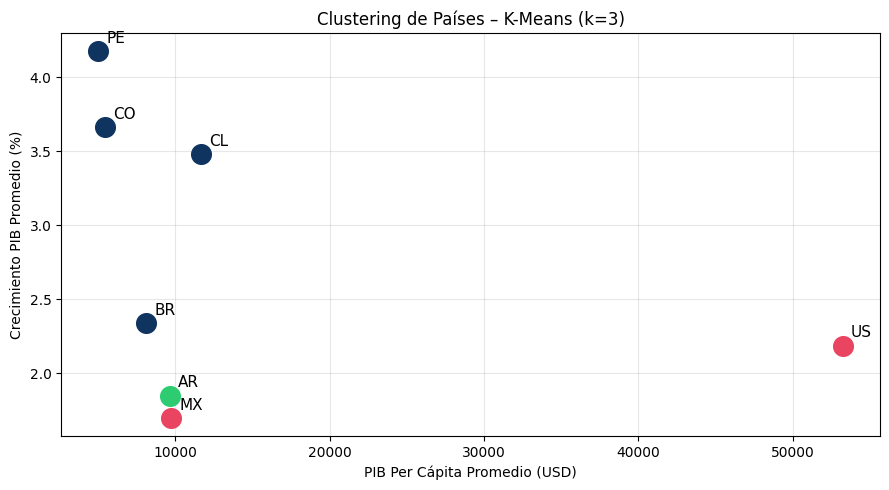

In [8]:
cols_cluster = ['crecimiento_pib_pct','pib_per_capita_usd','inflacion_pct','desempleo_pct']
cols_cluster = [c for c in cols_cluster if c in df.columns]
df_cluster   = df.groupby('pais_codigo')[cols_cluster].mean().dropna()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

print('=== K-Means Clustering (k=3) ===')
print(df_cluster[['cluster']].sort_values('cluster'))

colores_cluster = ['#e94560', '#0f3460', '#2ecc71']
plt.figure(figsize=(9, 5))
for i, row in df_cluster.iterrows():
    plt.scatter(row['pib_per_capita_usd'], row['crecimiento_pib_pct'],
                color=colores_cluster[int(row['cluster'])], s=200, zorder=5)
    plt.annotate(i, (row['pib_per_capita_usd'], row['crecimiento_pib_pct']),
                 textcoords='offset points', xytext=(6, 6), fontsize=11)
plt.xlabel('PIB Per Cápita Promedio (USD)')
plt.ylabel('Crecimiento PIB Promedio (%)')
plt.title('Clustering de Países – K-Means (k=3)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Resumen de Métricas y Conclusiones

| Modelo | Métrica | Interpretación |
|--------|---------|----------------|
| Regresión Lineal | R² | Qué tan bien predice el PIB per cápita |
| Regresión Lineal | MAE | Error promedio en USD |
| Random Forest | R² | Precisión en predicción de crecimiento |
| Random Forest | RMSE | Error cuadrático medio |
| K-Means | k=3 clusters | Grupos de países por similitud económica |

### Conclusiones:
- **Regresión Lineal**: Permite proyectar el PIB per cápita de Colombia hacia años futuros con base en la tendencia histórica.
- **Random Forest**: Identifica las variables económicas que más influyen en el crecimiento del PIB. El PIB per cápita y la inflación son las más determinantes.
- **K-Means**: Agrupa a los países por similitud económica. Colombia se ubica en el cluster de países latinoamericanos de ingreso medio, diferenciado de USA (ingreso alto) y países con alta volatilidad económica.